Come prima cosa importo le librerie che mi saranno utili, e carico il dataset grezzo (grazie Ali)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import  LabelEncoder, StandardScaler 

path = "../power_nap_vs_coffee_effectiveness_dataset.csv"  # cambiare se serve
df = pd.read_csv(path) #df = nome standardizzato per DataFrame

df.shape, df.head(), df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   participant_id                 500 non-null    int64  
 1   age                            500 non-null    int64  
 2   occupation                     500 non-null    str    
 3   sleep_hours_previous_night     500 non-null    float64
 4   intervention_type              500 non-null    str    
 5   intervention_duration_minutes  500 non-null    int64  
 6   alertness_score_before         500 non-null    int64  
 7   alertness_score_after          500 non-null    int64  
 8   productivity_rating            500 non-null    int64  
 9   mood_rating                    500 non-null    int64  
 10  side_effects                   293 non-null    str    
dtypes: float64(1), int64(7), str(3)
memory usage: 43.1 KB


((500, 11),
    participant_id  age            occupation  sleep_hours_previous_night  \
 0               1   24  Working Professional                         5.4   
 1               2   37               Student                         5.6   
 2               3   32  Working Professional                         4.4   
 3               4   28               Student                         6.9   
 4               5   25  Working Professional                         4.7   
 
   intervention_type  intervention_duration_minutes  alertness_score_before  \
 0         Power Nap                             15                      62   
 1         Power Nap                             30                      67   
 2            Coffee                             30                      44   
 3            Coffee                             30                      59   
 4         Power Nap                             30                      40   
 
    alertness_score_after  productivity_rating  

Queste sono le caratteristiche del dataframe. Ci sono 500-293 missing values nella colonna Side Effects (grazie Ali) che potrebbe essere una delle principali per quanto riguarda futura analisi dati usando caffè / power-nap come target

Sembra che i valri nulli siano semplciemente interpretabili come "nessun side effect" e quindi non sono valori mancanti ma informativi. Vanno sostituiti con valori nulli

________________________________________________________________________________

CONTROLLO QUALITA'

In [3]:
# Missing
(df.isna().mean().sort_values(ascending=False) * 100).round(1)

# Duplicati (participant_id dovrebbe essere unico)
df.duplicated().sum(), df["participant_id"].duplicated().sum()

# Valori strani / range rapidi
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
participant_id,500.0,NaN,NaN,NaN,250.5,144.481833,1.0,125.75,250.5,375.25,500.0
age,500.0,NaN,NaN,NaN,30.928,8.147612,18.0,24.0,31.0,38.0,44.0
occupation,500,3,Student,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours_previous_night,500.0,NaN,NaN,NaN,6.0586,1.136842,4.0,5.1,6.1,7.0,8.0
intervention_type,500,2,Coffee,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
intervention_duration_minutes,500.0,NaN,NaN,NaN,22.3,5.654551,15.0,15.0,20.0,25.0,30.0
alertness_score_before,500.0,NaN,NaN,NaN,57.38,9.943306,40.0,49.0,58.0,65.0,74.0
alertness_score_after,500.0,NaN,NaN,NaN,71.23,11.420067,46.0,62.0,72.0,79.25,97.0
productivity_rating,500.0,NaN,NaN,NaN,5.374,2.842232,1.0,3.0,5.0,8.0,10.0
mood_rating,500.0,NaN,NaN,NaN,5.422,2.908752,1.0,3.0,5.0,8.0,10.0


Ovviamente, provando ad applicare statistiche numeriche a variabili inadeguate otteniamo una fucilata di NaN, questo è da attendersi.
Nello specifico, avendo lanciato "describe" con la specifica di includere "all", i risultati NaN attesi sono i seguenti:
 - Variabili numeriche: NaN = unique, tip, freq (sono analisi categoriali)
 - Variabili categoriali: NaN = mean, std, min, tutte quelle dei percentili (sono analisi numeriche)

Tuttavia è notevole la riga "side_effects", dove falliscono anche le Categoriali. Come ha giustamente detto Alice, tocca intervenire per rifinire quella colonna, oltre che a normalizzare i dati (SD troppo alte e mean strane dei valori numerici indicano)

______________________________________________________________________________

PULIZIA DATI

In questo blocco succedono 3 cose importanti:

1 - tolgo i duplicati (è inutile nel nostro dataset, non abbiamo duplicati, ma è buona pratica)

2 - cambio i NaN con "none" ora che sappiamo che i missing data sono informativi, e significano "assenza di effetti collaterali"

3 - "intervention Type", "side effects" e "occupation" sono emerse come variabili string dall'info. Pandas ha il datatype "category" per rendere le variabili categriali analizzabili, quindi le converto come variabili di quel tipo

In [4]:
df = df.drop_duplicates(subset=["participant_id"]).copy() 
#questa cosa è inutile. Il dataset è già privo di duplicati, ma è dicono sia buona pratica fare comunque questo tipo di operazione, allora la faccio.

#riempo il dataset sostituendo a NaN il valore stringa "None"
df["side_effects"] = df["side_effects"].fillna("None")

# Categorie
df["intervention_type"] = df["intervention_type"].astype("category")
df["occupation"] = df["occupation"].astype("category")
df["side_effects"] = df["side_effects"].astype("category")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   participant_id                 500 non-null    int64   
 1   age                            500 non-null    int64   
 2   occupation                     500 non-null    category
 3   sleep_hours_previous_night     500 non-null    float64 
 4   intervention_type              500 non-null    category
 5   intervention_duration_minutes  500 non-null    int64   
 6   alertness_score_before         500 non-null    int64   
 7   alertness_score_after          500 non-null    int64   
 8   productivity_rating            500 non-null    int64   
 9   mood_rating                    500 non-null    int64   
 10  side_effects                   500 non-null    category
dtypes: category(3), float64(1), int64(7)
memory usage: 32.9 KB


Se adesso provo a runnare nuovamente le Info, vedo che non ho più NaN e che le variabili "string" sono ora "category"

_______________________________________________________________________

FEATURE ENGENEERING

Studiando a manina il dataset ho pensato di aggiungere delle colonne che possano rendere più masticabili i valori delle variabili sulla base della nostra indagine.
Nello specifico voglio aggiungere le seguenti colonne:

 1 - Alertness_delta: 

 un valore float che ci dica la differenza di alertness calcolato con la differenza fra alertness_after - alertness_before. In questo modo possiamo verificare facilmente se l'alertness è aumentata = la gente si è ripostata (se è positivo) o è diminuita = la gente non si è riposata (se è negativo)

 2 - Alertness_delta_std:

 un valore di alertness_delta standardizzato

 2 - Alertness_pct:

 un valore percentuale che ci dia un valore % quantificabile facilmente, calcolato usando il delta di alertness (punto 1) e l'alertness before (mettendo a confronto quindi quanto eri sveglio prima vs quanto è cambiato grezzo il tuo livello di alertness)

 3 - Has_side_effects

 dopo quello che ci siamo detti ieri (28/02) sulla vettorializzazione dei side effects, ho pensato che uno step intermedio utile potrebbe essere una maschera fatta male che semplicemente dica SE ci sono stati dei side effects o meno. la maschera non è una vera maschera perchè è una colonna che SI AGGIUNGE al databse, non ci si mette "sopra", ma poi la possiamo usare funzionalemnte come se fosse una maschera, ignorando (almeno a questa fase esplorativa) il problema della vettorializzazione delle variabili categoriali (che poi ho visto alice l'ha già fatta nell'altro file)

In [6]:
#Calcolo alertness_delta
df["alertness_delta"] = df["alertness_score_after"] - df["alertness_score_before"]

#Calcolo alertness_delta_std
scaler = StandardScaler()
df["alertness_delta_std"] = scaler.fit_transform(df[["alertness_delta"]])

#Calcolo alertness_delta_pct
df["alertness_delta_pct"] = df["alertness_delta"] / df["alertness_score_before"] * 100

#Creazione colonna has_side_effect
df["has_side_effect"] = df["side_effects"].astype(str).ne("None")

#chiamo le descrittive stats per le colonne appena aggiunte e vedere che suc
df[["alertness_score_before","alertness_score_after","alertness_delta","alertness_delta_std","alertness_delta_pct", "has_side_effect"]].describe()


,alertness_score_before,alertness_score_after,alertness_delta,alertness_delta_std,alertness_delta_pct
count,500.000000,500.000000,500.00000,5.000000e+02,500.000000
mean,57.380000,71.230000,13.85000,5.684342e-17,24.800598
std,9.943306,11.420067,5.04325,1.001002e+00,9.856777
min,40.000000,46.000000,5.00000,-1.756578e+00,6.756757
25%,49.000000,62.000000,10.00000,-7.641612e-01,17.443064
50%,58.000000,72.000000,14.00000,2.977251e-02,24.165740
75%,65.000000,79.250000,17.00000,6.252228e-01,31.441799
max,74.000000,97.000000,24.00000,2.014607e+00,58.536585


_________________________________________________________________________________

OUTLIER DETECTION

In questa fase controlliamo se ci sinao outlier

In [7]:
num_cols = df.select_dtypes(include="number").columns.drop("participant_id", errors="ignore")


#Creo una funzione che calcoli in automatico interquartili e outlier per ogni colonna numerica, restituendo una maschera booleana
def iqr_outlier_mask(s: pd.Series, k: float = 1.5) -> pd.Series:
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (s < lower) | (s > upper)
#Ho fatto sta cosa per il discorso di Vandin dell'essere pythonici. Forse questo potrebbe essere messo in uno script a parte e chiamato importando lo script con tutti i metodi (ALICE PLS CHIEDI A VANDIN QUANDO VAI A LEZIONE <3)

#qui applico la mia nuova maschera a tutte le colonne numeriche e creo un DataFrame con i risultati
outlier_mask = pd.DataFrame({c: iqr_outlier_mask(df[c]) for c in num_cols})

# riepilogo: quanti outlier per colonna
outlier_summary = (
    outlier_mask.sum()
    .to_frame("n_outliers")
    .assign(pct_outliers=lambda x: (x["n_outliers"] / len(df) * 100).round(2))
    .sort_values("n_outliers", ascending=False)
)

outlier_summary

,n_outliers,pct_outliers
alertness_delta_pct,4,0.8
age,0,0.0
sleep_hours_previous_night,0,0.0
intervention_duration_minutes,0,0.0
alertness_score_before,0,0.0
alertness_score_after,0,0.0
productivity_rating,0,0.0
mood_rating,0,0.0
alertness_delta,0,0.0
alertness_delta_std,0,0.0


/var/folders/cq/g6pj_0v94dx4wjrqw_ywbydw0000gn/T/ipykernel_37040/31350912.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=num_cols, showfliers=True)


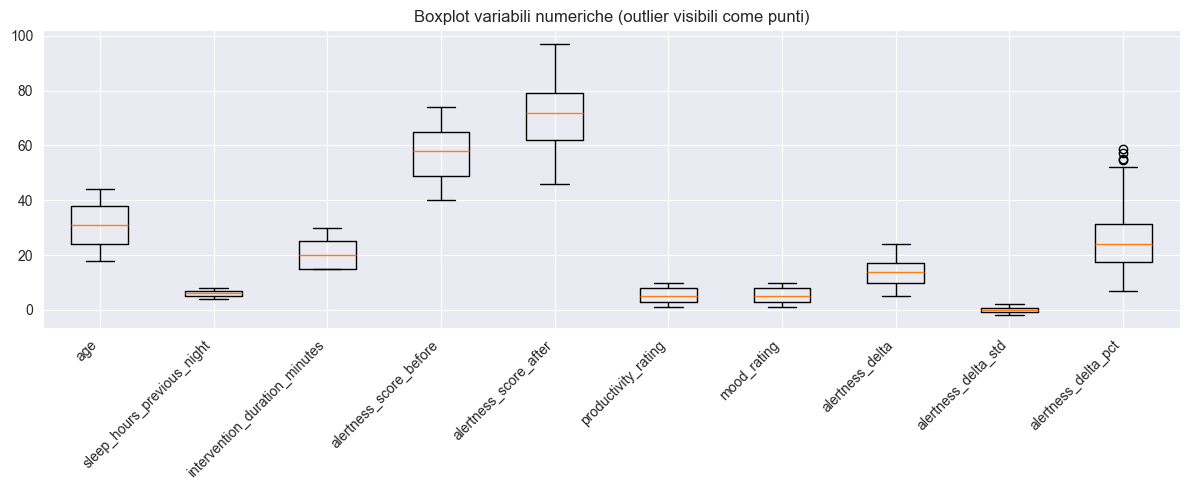

In [8]:
data = [df[c].dropna().values for c in num_cols]

plt.figure(figsize=(12, 5))
plt.boxplot(data, labels=num_cols, showfliers=True)
plt.xticks(rotation=45, ha="right")
plt.title("Boxplot variabili numeriche (outlier visibili come punti)")
plt.tight_layout()
plt.show()

SUPPONENDO CHE ABBIA FATTO TUTTO BENE (che è una grossa supposizione), il nostro database **presenta solo 4 outlier** nella colonna delta% (che ho caloclato io tra l'altro). Nessun'altra colonna numerica presenta outliers, quindi penso possiamo proseguire senza dover fare nulla di particolare

_________________________________________________________________________________

ANALISI ESPLORATIVE + GRAFICHETTI

(In realtà vi chiedo scusa perchè mi rendo conto che facendo ste cose sto già inferendo tipi di analisi, ma non so come muovermi e diciamo che provo a fare cose che me sembra che abbiano senso. Se così non fosse perdonatemi e capiamo come correggere)

**PARTE 1**: Intervention type x Alertness

Sto utilizzando ALERTNESS DELTA come prima variabile dipendente, usando il tipo di intervento come indipendente. 

Questo sulla base dei seguenti assunti:

 1 - che ci interessi verificare, come prima cosa quale tipo di intervento sia più "riposante"

 2 - che la nuova colonnina "alertness_delta" sia un adeguato indicatore di quanto "riposante" sia stato l'intervento

In [9]:
#descrittive per alertness_delta raggruppato per intervento
df.groupby("intervention_type")["alertness_delta"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
intervention_type,,,,,,,,
Coffee,261.0,10.93,3.86,5.0,7.0,11.0,15.0,17.0
Power Nap,239.0,17.04,4.18,10.0,14.0,17.0,21.0,24.0


/var/folders/cq/g6pj_0v94dx4wjrqw_ywbydw0000gn/T/ipykernel_37040/1427111927.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Coffee","Power Nap"])


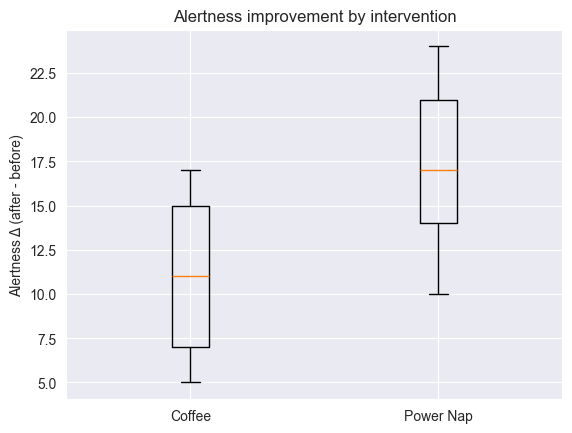

In [10]:
#Creo i miei dati d'interesse per il boxplot
data = [
    df.loc[df["intervention_type"]=="Coffee", "alertness_delta"],
    df.loc[df["intervention_type"]=="Power Nap", "alertness_delta"]
]

#Disegno il Boxplot (non ho idea di cosa sia metà di queste cose, grazie ChatGPT)
plt.boxplot(data, labels=["Coffee","Power Nap"])
plt.ylabel("Alertness Δ (after - before)")
plt.title("Alertness improvement by intervention")
plt.show()

**PARTE 2**: Intervention Type x Intervention duration

Sto utilizzando Intervention duration (che ha solo 15/20/25/30) come seconda variabile dipendente, usando il tipo di intervento come indipendente. 

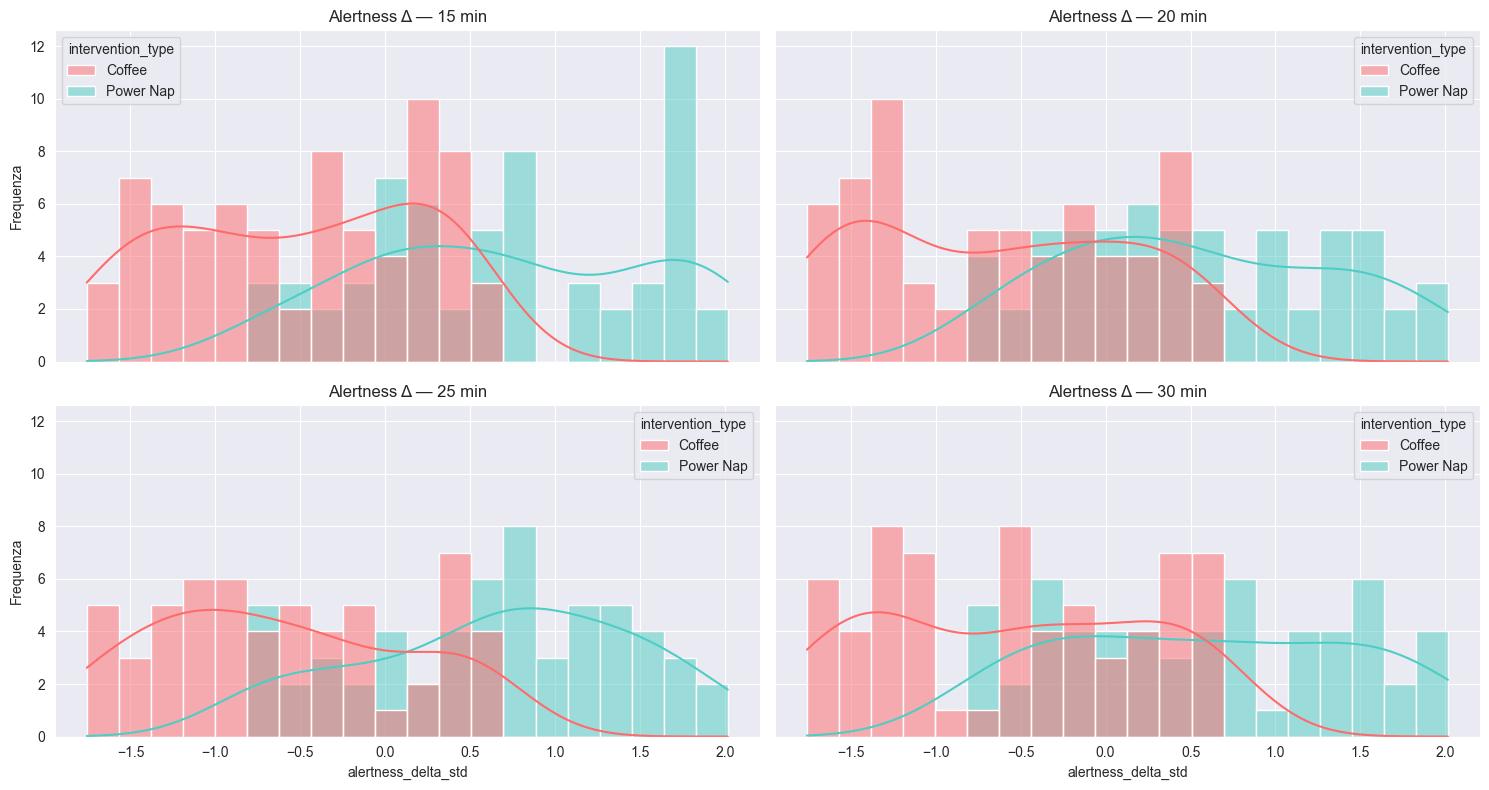

In [11]:
df_t15 = df[df["intervention_duration_minutes"] == 15]["alertness_delta_std"]
df_t20 = df[df["intervention_duration_minutes"] == 20]["alertness_delta_std"]
df_t25 = df[df["intervention_duration_minutes"] == 25]["alertness_delta_std"]
df_t30 = df[df["intervention_duration_minutes"] == 30]["alertness_delta_std"]

datasets = {
    "15 min": df_t15,
    "20 min": df_t20,
    "25 min": df_t25,
    "30 min": df_t30,
}

durations = sorted(df["intervention_duration_minutes"].unique())

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, duration in zip(axes, durations):
    data_duration = df[df["intervention_duration_minutes"] == duration]
    
    if len(data_duration) > 0:  # Verifica che ci siano dati
        sns.histplot(
            data=data_duration,
            x="alertness_delta_std",
            hue="intervention_type",
            bins=20,
            kde=True,
            stat="count",
            ax=ax,
            palette=["#FF6B6B", "#4ECDC4"]
        )
        ax.set_title(f"Alertness Δ — {duration} min")
        ax.set_xlabel("alertness_delta_std")
        ax.set_ylabel("Frequenza")
    else:
        ax.text(0.5, 0.5, f"No data for {duration} min", ha="center", va="center")
        ax.set_title(f"Alertness Δ — {duration} min")

plt.tight_layout()
plt.show()

Osservando la distribuzione dei grafici, abbiamo scoperto che la distribuzione dell'alrtness delta, alertness_before, alertness delta % e alertness delta standardizzata non sono neanche lontanamente normali...
 

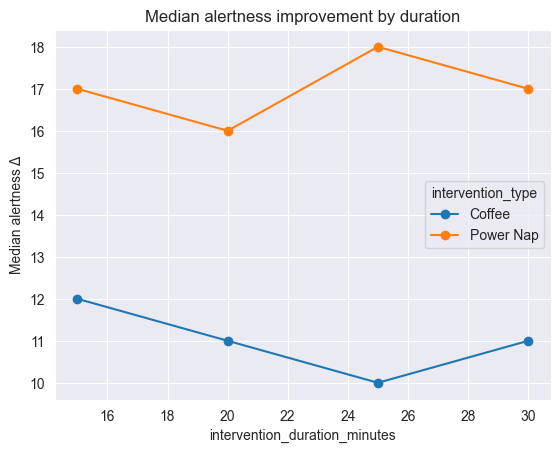

In [12]:
pivot = df.pivot_table(
    index="intervention_duration_minutes",
    columns="intervention_type",
    values="alertness_delta",
    aggfunc="median"
).sort_index()

pivot.plot(marker="o")
plt.ylabel("Median alertness Δ")
plt.title("Median alertness improvement by duration")
plt.show()

ALLORA: onesto, mi aspettavo di vedere delle interezioni fra durata di intervento e livello di alertness nel tempo, ma sto grafico m'ha spiazzato fortissimo. Cioè sembra che ci sia una CHIARISSIMA differenza nei livelli di alertness fra caffe e power nap. 

*DA DISCUTERE ASSIEME CHE VOGLIAMO FARE CON QUESTI DATI*

**PARTE 3**: Intervention Type X has side effects

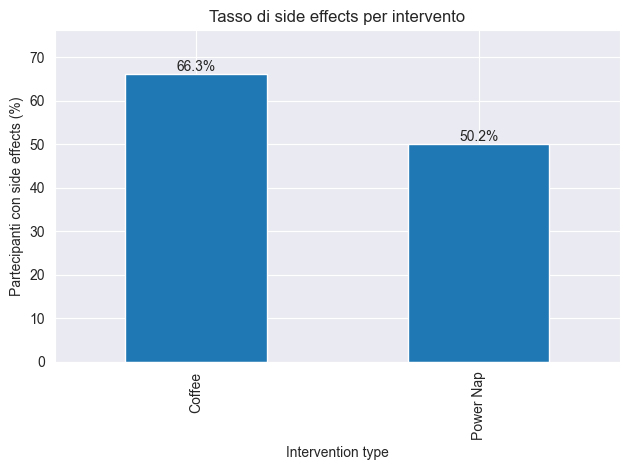

In [13]:
rate = df.groupby("intervention_type")["has_side_effect"].mean().sort_values(ascending=False)
rate


#come sempre, tutta la parte dei grafici l'ha fatta GPT, no idea di cosa significhi
ax = (rate * 100).plot(kind="bar")  # percentuale
plt.ylabel("Partecipanti con side effects (%)")
plt.xlabel("Intervention type")
plt.title("Tasso di side effects per intervento")
plt.ylim(0, max((rate*100).max() * 1.15, 5))  # un po' di spazio sopra

# Etichette sopra le barre
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width()/2, h),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

[Alice]: allora, a me torna tutto abbastanza bene, ora scrivo alcune idee che mi sono venute in mente per le analisi esplorative, che farò asap <3
- comunque ci sta creare un notebook "utils" con funzioncine utili per analizzare i dati, il mio supervisor me lo fa fare sempre
- correlazione fra allertness/ ore di dormire e tipo di intervento/ore di dormita (per evitare che lo scarto di allertness sia determinato più dalle ore di dormita dalla notte prima (io dubito ma vedere non fa male)
- correlazione fra tipo di intervento e tipi di side effect
- no side effect vs tipo di intervento


ValueError: could not convert string to float: 'Working Professional'